Input embedding + positional encoding

In [15]:
import torch
import torch.nn as nn
import math
import numpy as np
from torchviz import make_dot
from torchview import draw_graph
import graphviz


class Embeddings(nn.Module):
    """Embeddings
    """
    def __init__(self, vocab, d_model):
        super(Embeddings, self).__init__()
        # learnable lookup table shape (vocab, d_model)
        self.embedding = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        print(f"[EM]: x shape: {x.shape}")
        # x shape (sequences, seq_len)
        # embeddings shape (sequences, seq_len, d_model)
        return self.embedding(x) * math.sqrt(self.d_model)
    
class PositionalEncoder(nn.Module):
    """Positional Encoding for transformer model.
    """
    def __init__(self, device, d_model, seq_len, dropout):
        super(PositionalEncoder, self).__init__()
        self.d_model = d_model
        self.dropout = nn.Dropout(dropout)
        # Create positional encoding matrix (seq_len, d_model)
        # Even dimensions (i = 0, 2, 4, ...): PE(pos, i) = sin(pos / 10000^(i/d_model))
        # Odd dimensions (i = 1, 3, 5, ...): PE(pos, i) = cos(pos / 10000^(i/d_model))
        pe = torch.zeros(seq_len, d_model, device=device)
        print(f"pe initial shape: {pe.shape}")
        
        # Create the position matrix (seq_len, 1)
        position = torch.arange(0, seq_len, device=device).unsqueeze(1)
        print(f"position shape: {position.shape}")
        # Create the div_term matrix (d_model // 2,)
        # div_term_org = 1.0 / (10000.0 ** (torch.arange(0., d_model, 2, device=device).float() / d_model))
        div_term = torch.exp(torch.arange(0., d_model, 2, device=device) * - (math.log(10000.0) / d_model)).unsqueeze(0)
        # if torch.allclose(div_term_org, div_term):
        #     print(f"identical div_term")
        # else:
        #     print(f"div_terms are different")
        #     print(f"Max difference: {(div_term_org - div_term).abs().max()}")
        print(f"div_term shape: {div_term.shape}")
        # Create the pe_pos matrix
        # pe_pos = position.float() * div_term
        # pe_pos shape: (seq_len, d_model // 2)
        pe_pos = torch.mul(position, div_term)
        print(f"pe_pos shape: {pe_pos.shape}")

        # Apply sin to even indices
        pe[:, 0::2] = torch.sin(pe_pos)
        # Apply cos to odd indices
        pe[:, 1::2] = torch.cos(pe_pos)

        pe = pe.unsqueeze(0)
        print(f"pe final shape: {pe.shape}")
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        print(f"[PE]: x shape: {x.shape}")
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab = 1000
d_model = 512
seq_len = 100
drop_out = 0.1

input_embed = nn.Sequential(
    Embeddings(vocab, d_model),
    PositionalEncoder(device, d_model, seq_len, drop_out)
).to(device)

print("=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
print(input_embed)
print()

# Count parameters
total_params = sum(p.numel() for p in input_embed.parameters())
trainable_params = sum(p.numel() for p in input_embed.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print()

pe initial shape: torch.Size([100, 512])
position shape: torch.Size([100, 1])
div_term shape: torch.Size([1, 256])
pe_pos shape: torch.Size([100, 256])
pe final shape: torch.Size([1, 100, 512])
MODEL ARCHITECTURE
Sequential(
  (0): Embeddings(
    (embedding): Embedding(1000, 512)
  )
  (1): PositionalEncoder(
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

Total parameters: 512,000
Trainable parameters: 512,000



In [9]:
# train_tokenized_list:[1072]:
# input tokens
# [['BOS', 'i', 'do', "n't", 'have', 'a', 'lot', 'of', 'work', ',', 'but', 'it', "'s", 'enough', 'to', 'keep', 'me', 'in', 'the', 'office', 'this', 'week', '.', 'EOS']]:
# [[2, 5, 14, 13, 22, 9, 149, 17, 107, 24, 121, 16, 20, 267, 7, 181, 23, 15, 6, 422, 25, 220, 4, 3]]
# target tokens
# [['BOS', '其', '实', '我', '工', '作', '并', '不', '多', '，', '但', '足', '以', '让', '我', '这', '周', '在', '办', '公', '室', '里', '忙', '着', '了', '。', 'EOS']]:
# [[2, 453, 478, 5, 90, 70, 925, 13, 45, 20, 237, 402, 49, 177, 5, 28, 326, 12, 895, 148, 543, 75, 309, 143, 7, 4, 3]]
input_tokens = torch.tensor([[2, 5, 14, 13, 22, 9, 149, 17, 107, 24, 121, 16, 20, 267, 7, 181, 23, 15, 6, 422, 25, 220, 4, 3]], device=device)

# Forward pass
output = input_embed(input_tokens)
print(f"Input shape: {input_tokens.shape}")
print(f"Output shape: {output.shape}")
print()


x shape: torch.Size([1, 24, 512])
Input shape: torch.Size([1, 24])
Output shape: torch.Size([1, 24, 512])



VISUALIZATION 1: Computation Graph (torchviz)
✓ Computation graph saved as 'input_embed_computation_graph.png'


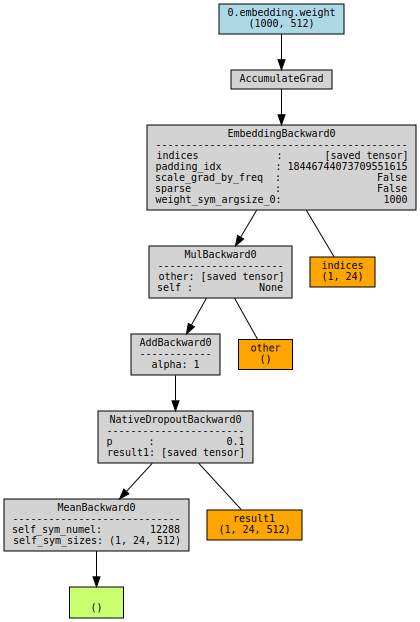

In [10]:
# ============================================================
# Visualization 1: Computation Graph with torchviz
# ============================================================
print("=" * 60)
print("VISUALIZATION 1: Computation Graph (torchviz)")
print("=" * 60)

try:
    # Create computation graph
    dot = make_dot(
        output.mean(),
        params=dict(input_embed.named_parameters()),
        show_attrs=True,
        show_saved=True
    )
    
    # Customize appearance
    dot.attr(rankdir='TB')  # Top to Bottom
    dot.attr('node', shape='box', style='rounded,filled', fillcolor='lightblue')
    
    # Save and display
    dot.render('input_embed_computation_graph', format='png', cleanup=True)
    print("✓ Computation graph saved as 'input_embed_computation_graph.png'")
    
    # Display in notebook
    display(dot)
    
except Exception as e:
    print(f"✗ Failed to generate computation graph: {e}")

print()

VISUALIZATION 2: Model Architecture (torchview)
x shape: torch.Size([1, 24, 512])
✓ Architecture diagram saved as 'input_embed_architecture.png'
✓ Model graph object created


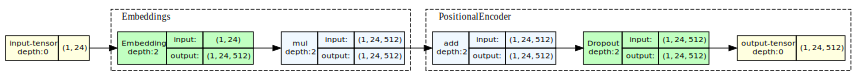

In [16]:
# ============================================================
# Visualization 2: Model Architecture with torchview
# ============================================================
print("=" * 60)
print("VISUALIZATION 2: Model Architecture (torchview)")
print("=" * 60)

try:
    model_graph = draw_graph(
        input_embed,
        input_data=input_tokens,
        graph_dir='LR', # Horizontal layout
                        # 'TB'	Top to Bottom	Vertical (default)
                        # 'LR'	Left to Right	Horizontal
                        # 'BT'	Bottom to Top	Vertical (reversed)
                        # 'RL'	Right to Left	Horizontal (reversed)
        device=device,
        expand_nested=True,
        graph_name='Input Embedding Pipeline',
        save_graph=True,
        filename='input_embed_architecture',
        directory='.'
    )
    
    print("✓ Architecture diagram saved as 'input_embed_architecture.png'")
    print(f"✓ Model graph object created")
    
    # Display visual graph
    display(model_graph.visual_graph)
    
except Exception as e:
    print(f"✗ Failed to generate architecture diagram: {e}")

print()

CUSTOM HORIZONTAL DIAGRAM (graphviz)
✓ Custom horizontal diagram saved as 'input_embed_custom_horizontal.png'


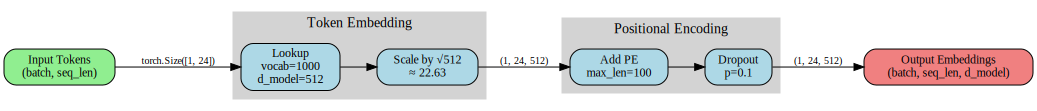

In [26]:
# ============================================================
# Method 2: Custom graphviz for more control
# ============================================================
print("=" * 60)
print("CUSTOM HORIZONTAL DIAGRAM (graphviz)")
print("=" * 60)

try:
    # Create a custom graphviz diagram
    dot = graphviz.Digraph(comment='Input Embedding Pipeline')
    dot.attr(rankdir='LR')  # Left to Right
    # dot.attr(rankdir='TB')  # Top to Bottom
    dot.attr('node', shape='box', style='rounded,filled', fillcolor='lightblue', fontsize='12')
    dot.attr('edge', fontsize='10')
    
    # Input node
    dot.node('input', 'Input Tokens\n(batch, seq_len)', fillcolor='lightgreen')
    
    # Embeddings block
    with dot.subgraph(name='cluster_0') as c:
        c.attr(label='Token Embedding', style='filled', color='lightgrey')
        c.node('emb_lookup', f'Lookup\nvocab={vocab}\nd_model={d_model}')
        c.node('emb_scale', f'Scale by √{d_model}\n≈ {math.sqrt(d_model):.2f}')
        c.edge('emb_lookup', 'emb_scale')
    
    # Positional Encoder block
    with dot.subgraph(name='cluster_1') as c:
        c.attr(label='Positional Encoding', style='filled', color='lightgrey')
        c.node('pe_add', f'Add PE\nmax_len={seq_len}')
        c.node('pe_dropout', f'Dropout\np={drop_out}')
        c.edge('pe_add', 'pe_dropout')
    
    # Output node
    dot.node('output', 'Output Embeddings\n(batch, seq_len, d_model)', fillcolor='lightcoral')
    
    # Connect blocks
    dot.edge('input', 'emb_lookup', label=f'{input_tokens.shape}')
    dot.edge('emb_scale', 'pe_add', label=f'({input_tokens.shape[0]}, {input_tokens.shape[1]}, {d_model})')
    dot.edge('pe_dropout', 'output', label=f'({input_tokens.shape[0]}, {input_tokens.shape[1]}, {d_model})')
    
    # Render
    dot.render('input_embed_custom_horizontal', format='png', cleanup=True)
    print("✓ Custom horizontal diagram saved as 'input_embed_custom_horizontal.png'")
    
    # Display in notebook
    display(dot)
    
except Exception as e:
    print(f"✗ Failed to generate custom diagram: {e}")

print()


SIMPLIFIED BLOCK DIAGRAM
✓ Simplified diagram saved as 'input_embed_simplified.png'


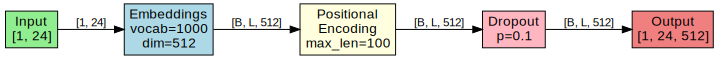


VISUALIZATION COMPLETE


In [22]:

# ============================================================
# Method 3: Simplified block diagram
# ============================================================
print("=" * 60)
print("SIMPLIFIED BLOCK DIAGRAM")
print("=" * 60)

try:
    dot = graphviz.Digraph(comment='Simplified Pipeline')
    dot.attr(rankdir='LR', size='10,3')
    dot.attr('node', shape='box', style='filled', fillcolor='skyblue', fontname='Arial', fontsize='14')
    dot.attr('edge', fontsize='12', fontname='Arial')
    
    # Nodes
    dot.node('A', f'Input\n{list(input_tokens.shape)}', fillcolor='lightgreen')
    dot.node('B', f'Embeddings\nvocab={vocab}\ndim={d_model}', fillcolor='lightblue')
    dot.node('C', f'Positional\nEncoding\nmax_len={seq_len}', fillcolor='lightyellow')
    dot.node('D', f'Dropout\np={drop_out}', fillcolor='lightpink')
    dot.node('E', f'Output\n[{input_tokens.shape[0]}, {input_tokens.shape[1]}, {d_model}]', fillcolor='lightcoral')
    
    # Edges with shapes
    dot.edge('A', 'B', label=f'{list(input_tokens.shape)}')
    dot.edge('B', 'C', label=f'[B, L, {d_model}]')
    dot.edge('C', 'D', label=f'[B, L, {d_model}]')
    dot.edge('D', 'E', label=f'[B, L, {d_model}]')
    
    # Render
    dot.render('input_embed_simplified', format='png', cleanup=True)
    print("✓ Simplified diagram saved as 'input_embed_simplified.png'")
    
    # Display in notebook
    display(dot)
    
except Exception as e:
    print(f"✗ Failed to generate simplified diagram: {e}")

print()
print("=" * 60)
print("VISUALIZATION COMPLETE")
print("=" * 60)

In [17]:
# ============================================================
# Visualization 3: Layer-by-layer Analysis
# ============================================================
print("=" * 60)
print("VISUALIZATION 3: Layer-by-layer Analysis")
print("=" * 60)

x = input_tokens
for i, layer in enumerate(input_embed):
    x = layer(x)
    print(f"Layer {i} ({layer.__class__.__name__}):")
    print(f"  Output shape: {x.shape}")
    print(f"  Output range: [{x.min().item():.4f}, {x.max().item():.4f}]")
    print(f"  Output mean: {x.mean().item():.4f}")
    print(f"  Output std: {x.std().item():.4f}")
    print()

VISUALIZATION 3: Layer-by-layer Analysis
Layer 0 (Embeddings):
  Output shape: torch.Size([1, 24, 512])
  Output range: [-84.2946, 93.2573]
  Output mean: -0.1012
  Output std: 22.7829

x shape: torch.Size([1, 24, 512])
Layer 1 (PositionalEncoder):
  Output shape: torch.Size([1, 24, 512])
  Output range: [-92.5904, 103.6208]
  Output mean: 0.2909
  Output std: 24.0470



In [13]:
# ============================================================
# Visualization 4: Export to ONNX
# ============================================================
print("=" * 60)
print("VISUALIZATION 4: ONNX Export")
print("=" * 60)

try:
    torch.onnx.export(
        input_embed,
        input_tokens,
        "input_embed_model.onnx",
        input_names=["input_tokens"],
        output_names=["embeddings"],
        opset_version=11,
        dynamic_axes={
            'input_tokens': {0: 'batch_size', 1: 'seq_len'},
            'embeddings': {0: 'batch_size', 1: 'seq_len'}
        }
    )
    print("✓ ONNX model saved as 'input_embed_model.onnx'")
    print("\nTo visualize ONNX model:")
    print("  1. Install: pip install netron")
    print("  2. Run: netron input_embed_model.onnx")
    
except Exception as e:
    print(f"✗ Failed to export ONNX: {e}")

print()
print("=" * 60)
print("VISUALIZATION COMPLETE")
print("=" * 60)

VISUALIZATION 4: ONNX Export
x shape: torch.Size([1, 24, 512])
✓ ONNX model saved as 'input_embed_model.onnx'

To visualize ONNX model:
  1. Install: pip install netron
  2. Run: netron input_embed_model.onnx

VISUALIZATION COMPLETE


In [19]:
# Alternative: Simpler Visualization
# If you want a quick visualization without external dependencies:

# Simple text-based visualization
def visualize_sequential(model, input_shape):
    print("=" * 60)
    print("MODEL PIPELINE")
    print("=" * 60)
    
    current_shape = input_shape
    print(f"Input: {current_shape}")
    print("  ↓")
    
    for i, layer in enumerate(model):
        layer_name = layer.__class__.__name__
        
        # Estimate output shape
        if isinstance(layer, Embeddings):
            current_shape = (*current_shape, layer.d_model)
        
        print(f"Layer {i}: {layer_name}")
        print(f"  Output: {current_shape}")
        
        # Show parameters
        params = sum(p.numel() for p in layer.parameters())
        if params > 0:
            print(f"  Parameters: {params:,}")
        
        print("  ↓")
    
    print(f"Final Output: {current_shape}")
    print("=" * 60)

visualize_sequential(input_embed, (1, input_tokens.size(1)))  # batch_size=1, seq_len=10


MODEL PIPELINE
Input: (1, 24)
  ↓
Layer 0: Embeddings
  Output: (1, 24)
  Parameters: 512,000
  ↓
Layer 1: PositionalEncoder
  Output: (1, 24)
  ↓
Final Output: (1, 24)
